# Quebras estruturais e eventos

**Objetivo:** verificar se a serie muda de regime ao longo do tempo, comparar periodos relevantes e detectar possiveis pontos de ruptura.

Em series de saude isso e especialmente importante porque nem sempre faz sentido assumir que o processo gerador dos dados foi estavel do inicio ao fim. Mudancas de comportamento podem refletir:
- ondas epidemiologicas;
- alteracoes de notificacao ou acesso ao sistema;
- mudancas abruptas de nivel medio e de variabilidade.

Nesta etapa vamos combinar:
- comparacao entre **blocos temporais do proprio periodo estudado**;
- deteccao de **ondas** com base na media movel de 30 dias;
- inspeccao de mudancas abruptas de **nivel** e **variancia**;
- deteccao automatica de **changepoints** em escala mensal.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from scipy.stats import rankdata

In [8]:
def classificar_bloco_temporal(data):
    if data < pd.Timestamp("2014-01-01"):
        return "2012-2013"
    if data < pd.Timestamp("2016-01-01"):
        return "2014-2015"
    return "2016-2018"


def pettitt_test(serie):
    """Teste de Pettitt para detectar uma quebra principal em uma serie ordenada."""
    serie = serie.dropna()
    x = serie.to_numpy(dtype=float)
    n = len(x)
    ranks = rankdata(x)
    u_t = 2 * np.cumsum(ranks) - np.arange(1, n + 1) * (n + 1)
    k = np.abs(u_t).max()
    t = int(np.abs(u_t).argmax())
    p = float(min(1.0, 2 * np.exp((-6 * (k**2)) / (n**3 + n**2))))
    return {
        "data_changepoint": serie.index[t],
        "estatistica_k": float(k),
        "p_valor_aprox": p,
        "n_observacoes": int(n),
    }


def detectar_candidatos_por_score(serie_score, distance=45, quantil_prom=0.90, top_n=8):
    """Detecta datas candidatas de ruptura a partir de um escore de mudanca."""
    serie_score = serie_score.dropna().copy()
    if serie_score.empty:
        return pd.DataFrame(columns=["data", "score", "prominencia"])

    prominencia_ref = float(serie_score.quantile(quantil_prom))
    if prominencia_ref <= 0:
        prominencia_ref = float(max(serie_score.std(), 1e-6))

    peaks, props = find_peaks(serie_score.to_numpy(), distance=distance, prominence=prominencia_ref)

    if len(peaks) == 0:
        fallback = serie_score.nlargest(top_n)
        return pd.DataFrame({"data": fallback.index, "score": fallback.values, "prominencia": np.nan})

    return pd.DataFrame(
        {
            "data": serie_score.index[peaks],
            "score": serie_score.iloc[peaks].to_numpy(),
            "prominencia": props["prominences"],
        }
    ).sort_values("score", ascending=False).head(top_n)


def normalizar_z(serie):
    serie = serie.astype(float)
    desvio = serie.std()
    if pd.isna(desvio) or desvio == 0:
        return pd.Series(np.zeros(len(serie)), index=serie.index)
    return (serie - serie.mean()) / desvio

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro entre 2012 e 2018

In [ ]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.parquet"

df_internacoes = pd.read_parquet(url_internacoes)

df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)
df_serie = df_serie[(df_serie["data_dia"] >= pd.Timestamp("2012-01-01")) & (df_serie["data_dia"] <= pd.Timestamp("2018-12-31"))].copy()

## Quebras estruturais e eventos

In [4]:
serie_eventos = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

faltantes_eventos = int(serie_eventos.isna().sum())
if faltantes_eventos > 0:
    print(f"Foram encontrados {faltantes_eventos} dias faltantes. A serie sera interpolada para a analise de quebras estruturais.")
    serie_eventos = serie_eventos.interpolate(method="time")
else:
    print("Nenhum dia faltante foi encontrado para a analise de quebras estruturais.")

df_eventos = pd.DataFrame(index=serie_eventos.index)
df_eventos["num_internacoes"] = serie_eventos
df_eventos["ano"] = df_eventos.index.year
df_eventos["bloco_temporal"] = pd.Categorical(
    df_eventos.index.to_series().apply(classificar_bloco_temporal),
    categories=["2012-2013", "2014-2015", "2016-2018"],
    ordered=True,
)
df_eventos["fase_estrutura"] = pd.Categorical(
    np.where(df_eventos.index < pd.Timestamp("2016-01-01"), "2012-2015", "2016-2018"),
    categories=["2012-2015", "2016-2018"],
    ordered=True,
)
df_eventos["media_movel_7d"] = df_eventos["num_internacoes"].rolling(window=7, min_periods=1).mean()
df_eventos["media_movel_30d"] = df_eventos["num_internacoes"].rolling(window=30, min_periods=1).mean()
df_eventos["desvio_movel_30d"] = df_eventos["num_internacoes"].rolling(window=30, min_periods=10).std()

display(df_eventos.head(10))

Nenhum dia faltante foi encontrado para a analise de quebras estruturais.


,num_internacoes,ano,bloco_temporal,fase_estrutura,media_movel_7d,media_movel_30d,desvio_movel_30d
data_dia,,,,,,,
2012-01-01,490,2012,2012-2013,2012-2015,490.000000,490.000000,NaN
2012-01-02,672,2012,2012-2013,2012-2015,581.000000,581.000000,NaN
2012-01-03,462,2012,2012-2013,2012-2015,541.333333,541.333333,NaN
2012-01-04,490,2012,2012-2013,2012-2015,528.500000,528.500000,NaN
2012-01-05,378,2012,2012-2013,2012-2015,498.400000,498.400000,NaN
2012-01-06,518,2012,2012-2013,2012-2015,501.666667,501.666667,NaN
2012-01-07,280,2012,2012-2013,2012-2015,470.000000,470.000000,NaN
2012-01-08,378,2012,2012-2013,2012-2015,454.000000,458.500000,NaN
2012-01-09,448,2012,2012-2013,2012-2015,422.000000,457.333333,NaN


### Comparacao entre blocos temporais do estudo

A ideia aqui e verificar se o nivel medio e a variabilidade da serie mudaram de forma relevante entre fases do proprio periodo analisado. Usamos uma divisao em tres blocos temporais (`2012-2013`, `2014-2015` e `2016-2018`) e tambem uma comparacao binaria simples entre a fase inicial/intermediaria (`2012-2015`) e a fase mais recente (`2016-2018`).

,bloco_temporal,n_dias,total,media,mediana,desvio_padrao,p95
0,2012-2013,731,372477,509.54,481.0,201.59,897.00
1,2014-2015,730,288395,395.06,374.0,155.63,694.65
2,2016-2018,1096,287633,262.44,243.0,110.84,470.50


,fase_estrutura,n_dias,media,mediana,desvio_padrao,p95
0,2012-2015,1461,452.34,418.0,188.92,819.0
1,2016-2018,1096,262.44,243.0,110.84,470.5


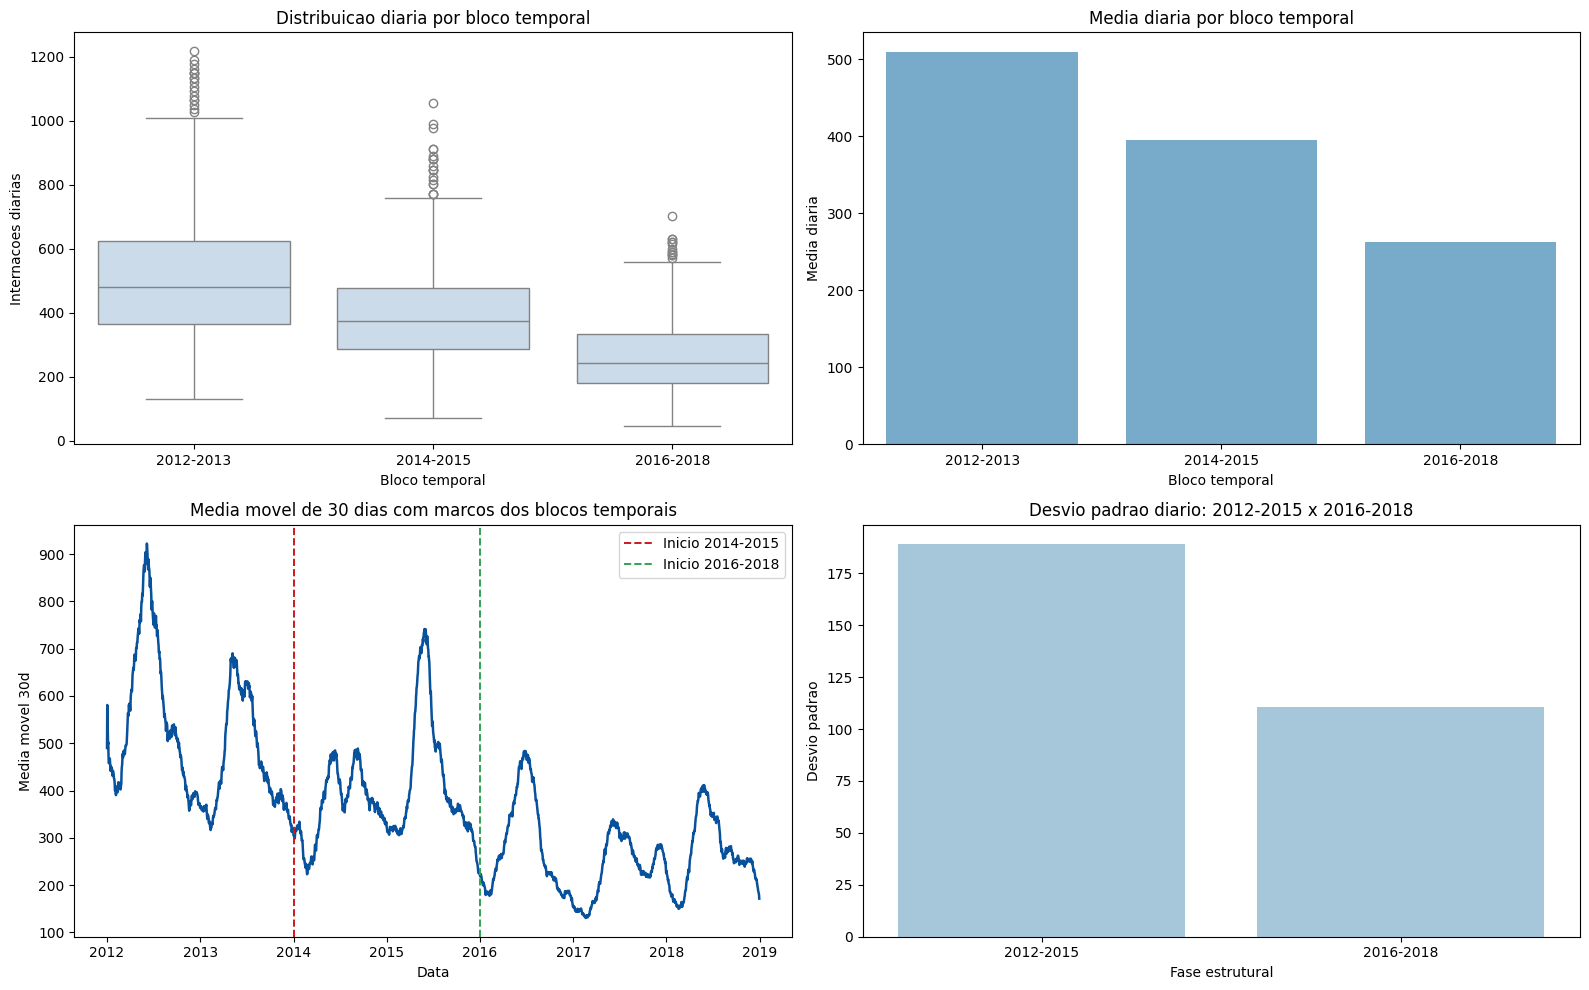

In [5]:
resumo_bloco_temporal = (
    df_eventos.groupby("bloco_temporal", observed=True)["num_internacoes"]
    .agg(
        n_dias="count",
        total="sum",
        media="mean",
        mediana="median",
        desvio_padrao="std",
        p95=lambda s: s.quantile(0.95),
    )
    .reset_index()
)

resumo_fase_estrutura = (
    df_eventos.groupby("fase_estrutura", observed=True)["num_internacoes"]
    .agg(n_dias="count", media="mean", mediana="median", desvio_padrao="std", p95=lambda s: s.quantile(0.95))
    .reset_index()
)

display(resumo_bloco_temporal.round(2))
display(resumo_fase_estrutura.round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(data=df_eventos.reset_index(), x="bloco_temporal", y="num_internacoes", color="#c6dbef", ax=axes[0, 0])
axes[0, 0].set_title("Distribuicao diaria por bloco temporal")
axes[0, 0].set_xlabel("Bloco temporal")
axes[0, 0].set_ylabel("Internacoes diarias")

sns.barplot(data=resumo_bloco_temporal, x="bloco_temporal", y="media", color="#6baed6", ax=axes[0, 1])
axes[0, 1].set_title("Media diaria por bloco temporal")
axes[0, 1].set_xlabel("Bloco temporal")
axes[0, 1].set_ylabel("Media diaria")

axes[1, 0].plot(df_eventos.index, df_eventos["media_movel_30d"], color="#08519c", linewidth=1.8)
for data_ref, cor, rotulo in [
    (pd.Timestamp("2014-01-01"), "#cb181d", "Inicio 2014-2015"),
    (pd.Timestamp("2016-01-01"), "#31a354", "Inicio 2016-2018"),
]:
    axes[1, 0].axvline(data_ref, color=cor, linestyle="--", linewidth=1.4, label=rotulo)
axes[1, 0].set_title("Media movel de 30 dias com marcos dos blocos temporais")
axes[1, 0].set_xlabel("Data")
axes[1, 0].set_ylabel("Media movel 30d")
axes[1, 0].legend()

sns.barplot(data=resumo_fase_estrutura, x="fase_estrutura", y="desvio_padrao", color="#9ecae1", ax=axes[1, 1])
axes[1, 1].set_title("Desvio padrao diario: 2012-2015 x 2016-2018")
axes[1, 1].set_xlabel("Fase estrutural")
axes[1, 1].set_ylabel("Desvio padrao")

plt.tight_layout()
plt.show()

### Ondas epidemicas e mudancas abruptas de nivel/variancia

Para identificar ondas, usamos a media movel de 30 dias e procuramos picos suficientemente separados no tempo. Para detectar mudancas abruptas de nivel e de variabilidade, construimos escores baseados na diferenca entre as janelas atuais e as de 30 dias atras.

,data_pico,media_movel_30d,prominencia
1,2012-06-05,922.60,532.47
5,2015-05-29,741.77,518.97
2,2013-05-07,690.30,373.97
0,2012-01-02,581.00,91.00
4,2014-09-10,488.87,183.43
3,2014-06-13,484.80,130.97
6,2016-06-24,483.63,305.97
8,2018-05-29,411.47,240.30
7,2017-06-06,339.00,189.40


,data,score,prominencia
4,2015-05-05,263.63,263.60
2,2013-04-30,236.17,235.63
5,2015-07-09,235.83,232.90
1,2012-08-12,194.33,181.70
0,2012-06-05,190.87,176.40
6,2016-08-28,154.70,153.67
3,2013-08-22,153.00,152.57


,data,score,prominencia
3,2013-04-11,90.34,90.25
8,2015-04-20,86.35,86.35
1,2012-07-12,84.73,83.58
9,2015-07-20,82.01,81.24
4,2013-09-06,55.79,54.77
0,2012-03-27,49.82,41.30
10,2016-01-09,49.43,49.37
6,2014-05-23,48.74,48.65


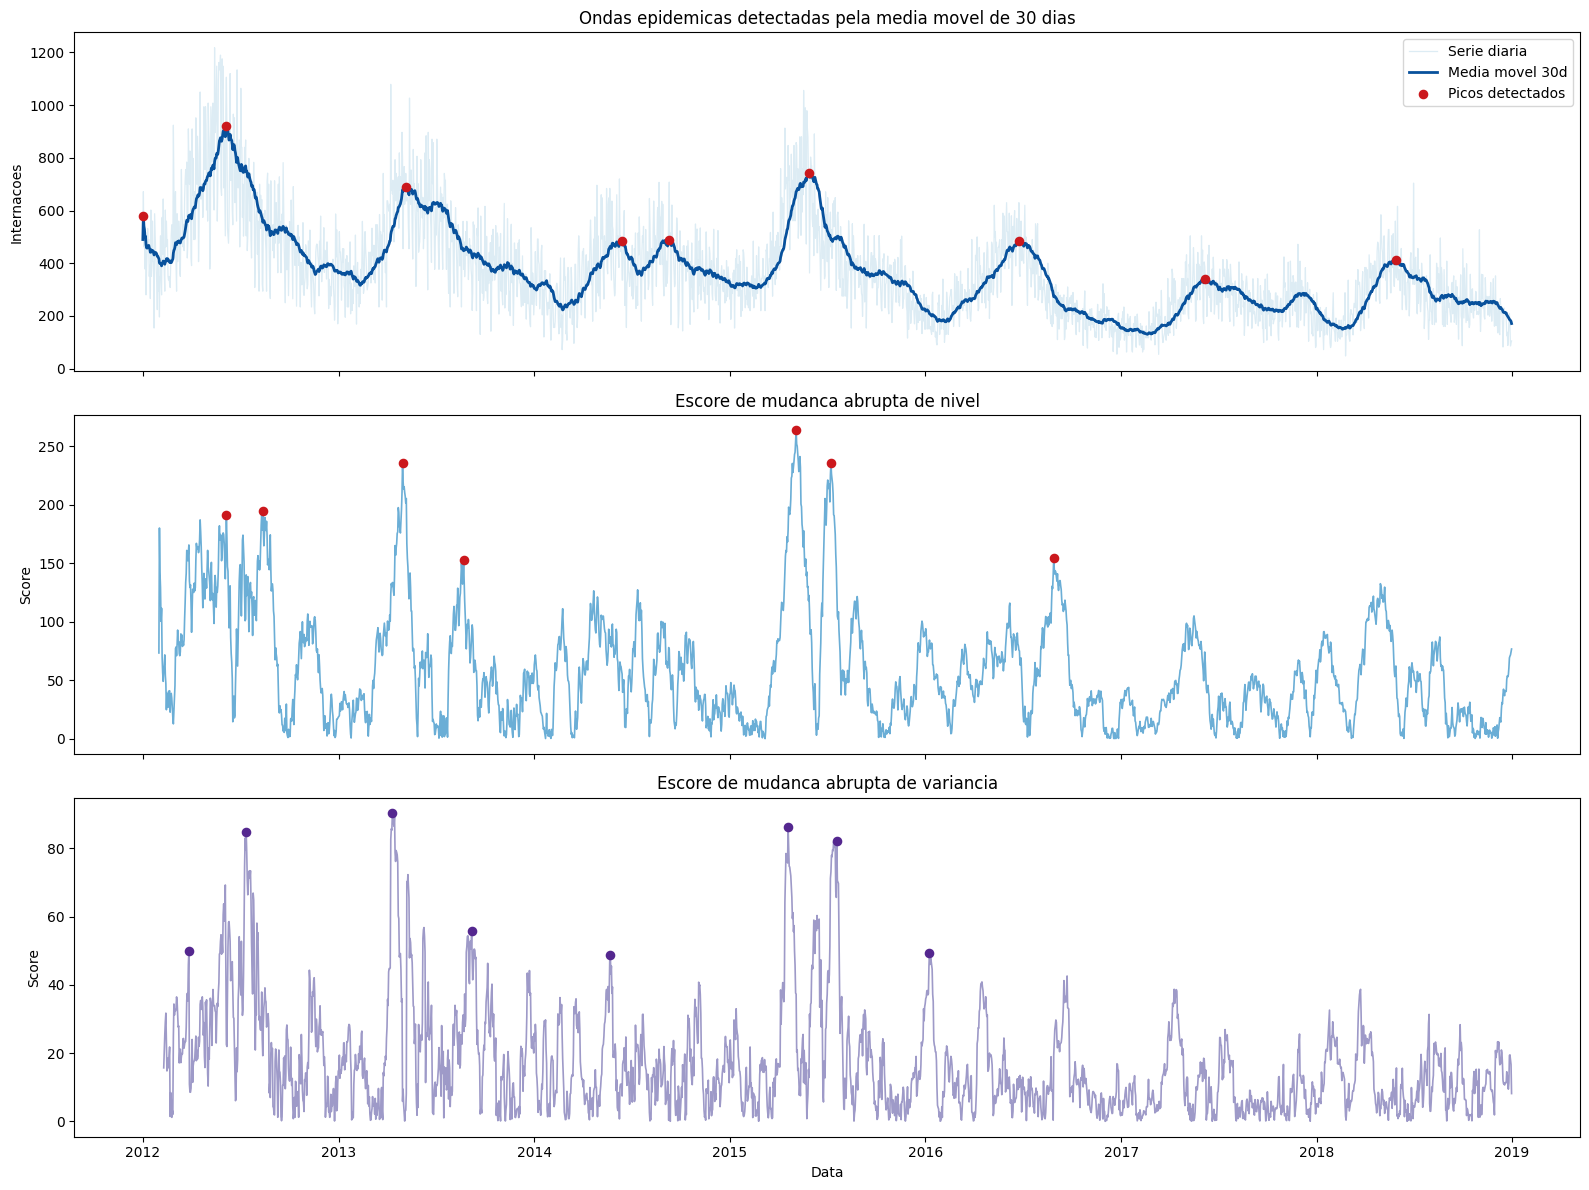

In [6]:
# Deteccao de ondas a partir da media movel de 30 dias.
serie_ondas = df_eventos["media_movel_30d"].dropna()
prominencia_ondas = max(float(serie_ondas.std() * 0.5), 5.0)
peaks_ondas, props_ondas = find_peaks(serie_ondas.to_numpy(), distance=45, prominence=prominencia_ondas)

ondas_detectadas = pd.DataFrame(
    {
        "data_pico": serie_ondas.index[peaks_ondas],
        "media_movel_30d": serie_ondas.iloc[peaks_ondas].to_numpy(),
        "prominencia": props_ondas.get("prominences", np.array([])),
    }
).sort_values("media_movel_30d", ascending=False)

# Escores diarios de mudanca de nivel e de variancia.
janela_mudanca = 30
df_eventos["score_mudanca_nivel"] = (df_eventos["media_movel_30d"] - df_eventos["media_movel_30d"].shift(janela_mudanca)).abs()
df_eventos["score_mudanca_variancia"] = (df_eventos["desvio_movel_30d"] - df_eventos["desvio_movel_30d"].shift(janela_mudanca)).abs()

candidatos_nivel = detectar_candidatos_por_score(df_eventos["score_mudanca_nivel"], distance=60, quantil_prom=0.92, top_n=8)
candidatos_variancia = detectar_candidatos_por_score(df_eventos["score_mudanca_variancia"], distance=60, quantil_prom=0.92, top_n=8)

display(ondas_detectadas.head(10).round(2))
display(candidatos_nivel.round(2))
display(candidatos_variancia.round(2))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(df_eventos.index, df_eventos["num_internacoes"], color="#9ecae1", alpha=0.35, linewidth=0.9, label="Serie diaria")
axes[0].plot(df_eventos.index, df_eventos["media_movel_30d"], color="#08519c", linewidth=2, label="Media movel 30d")
axes[0].scatter(ondas_detectadas["data_pico"], ondas_detectadas["media_movel_30d"], color="#cb181d", s=35, zorder=3, label="Picos detectados")
axes[0].set_title("Ondas epidemicas detectadas pela media movel de 30 dias")
axes[0].set_ylabel("Internacoes")
axes[0].legend(loc="upper right")

axes[1].plot(df_eventos.index, df_eventos["score_mudanca_nivel"], color="#6baed6", linewidth=1.2)
axes[1].scatter(candidatos_nivel["data"], candidatos_nivel["score"], color="#cb181d", s=35, zorder=3)
axes[1].set_title("Escore de mudanca abrupta de nivel")
axes[1].set_ylabel("Score")

axes[2].plot(df_eventos.index, df_eventos["score_mudanca_variancia"], color="#9e9ac8", linewidth=1.2)
axes[2].scatter(candidatos_variancia["data"], candidatos_variancia["score"], color="#54278f", s=35, zorder=3)
axes[2].set_title("Escore de mudanca abrupta de variancia")
axes[2].set_xlabel("Data")
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()

### Changepoints em escala mensal

Para reduzir ruido diario e detectar melhor mudancas estruturais, agregamos a serie por mes. Depois aplicamos duas abordagens:
- **Pettitt**, para encontrar um ponto principal de ruptura;
- um **escore combinado** de mudanca de nivel e variabilidade mensal, para levantar varios changepoints candidatos.

,data_changepoint,estatistica_k,p_valor_aprox,n_observacoes
0,2015-09-01,1443.0,0.0,84


,data_changepoint,score,prominencia,media_mensal,desvio_mensal,score_changepoint
3,2015-04-01,6.631,6.200,625.533,136.712,6.631
0,2012-05-01,5.579,3.738,893.290,242.525,5.579
1,2013-04-01,4.085,3.578,679.033,119.425,4.085
2,2013-08-01,3.609,3.058,448.613,95.162,3.609


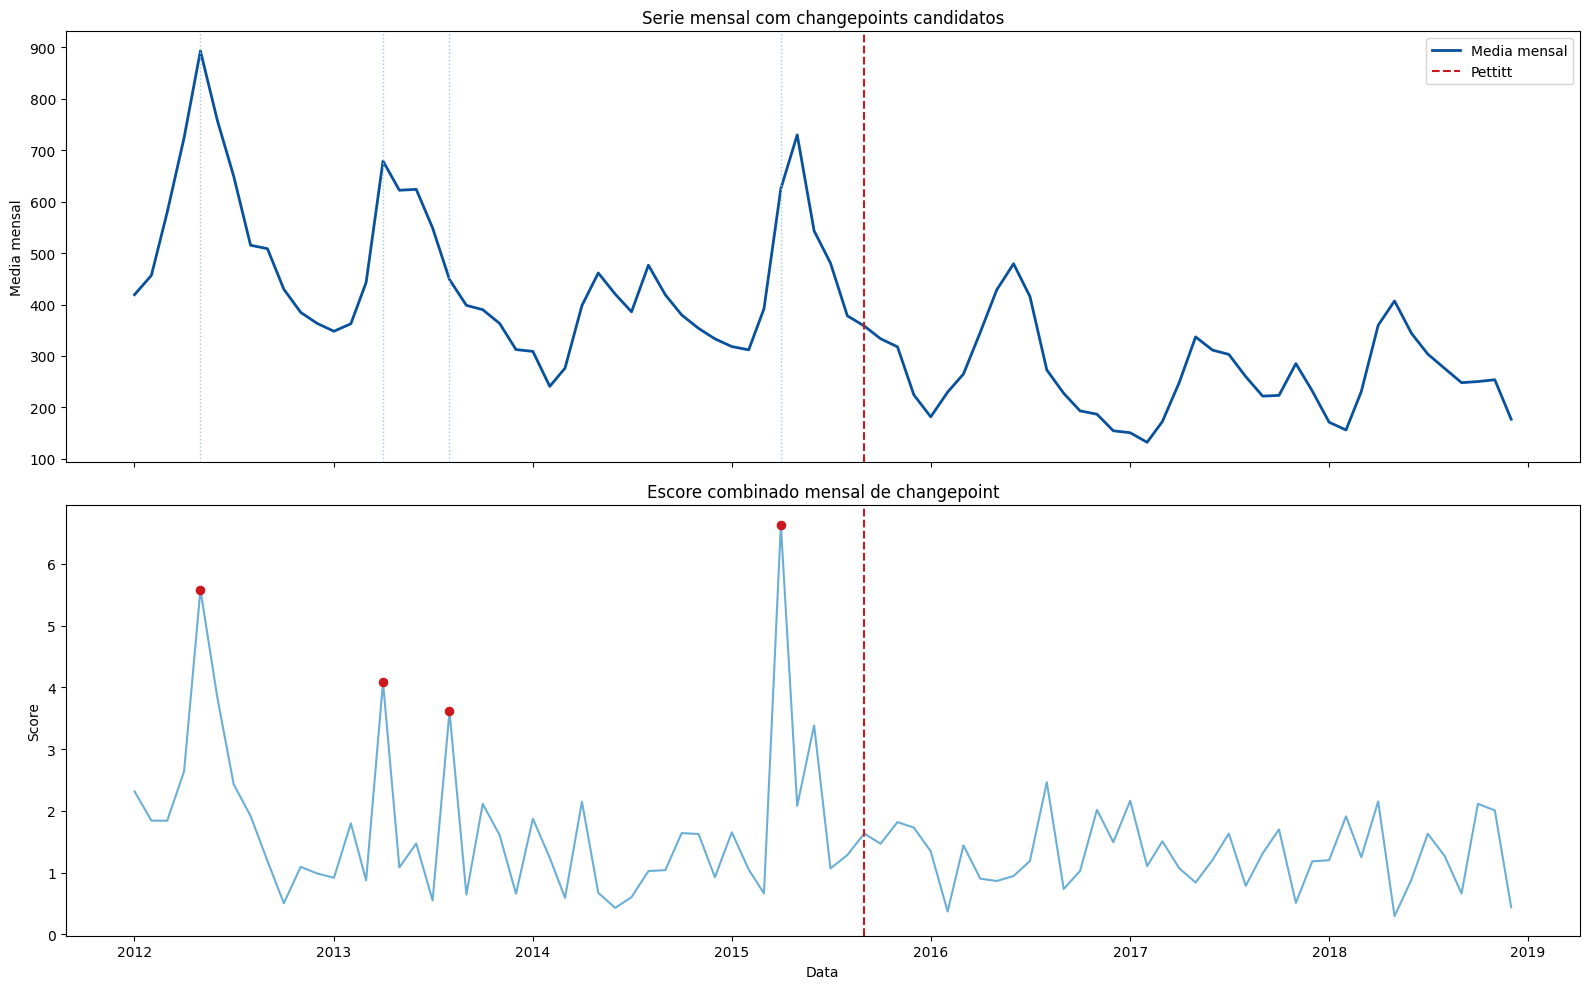

In [7]:
mensal_eventos = (
    df_eventos["num_internacoes"]
    .resample("MS")
    .agg(["mean", "median", "std", "sum"])
    .rename(columns={"mean": "media_mensal", "median": "mediana_mensal", "std": "desvio_mensal", "sum": "total_mensal"})
)

mensal_eventos["delta_media_abs"] = mensal_eventos["media_mensal"].diff().abs()
mensal_eventos["delta_desvio_abs"] = mensal_eventos["desvio_mensal"].diff().abs()
mensal_eventos["score_changepoint"] = normalizar_z(mensal_eventos["delta_media_abs"].fillna(0)).abs() + normalizar_z(mensal_eventos["delta_desvio_abs"].fillna(0)).abs()

resultado_pettitt = pettitt_test(mensal_eventos["media_mensal"])

candidatos_changepoint = detectar_candidatos_por_score(
    mensal_eventos["score_changepoint"],
    distance=2,
    quantil_prom=0.85,
    top_n=8,
).rename(columns={"data": "data_changepoint"})

candidatos_changepoint = candidatos_changepoint.merge(
    mensal_eventos[["media_mensal", "desvio_mensal", "score_changepoint"]],
    left_on="data_changepoint",
    right_index=True,
    how="left",
)

display(pd.DataFrame([resultado_pettitt]).round(4))
display(candidatos_changepoint.round(3))

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(mensal_eventos.index, mensal_eventos["media_mensal"], color="#08519c", linewidth=2, label="Media mensal")
axes[0].axvline(resultado_pettitt["data_changepoint"], color="#cb181d", linestyle="--", linewidth=1.5, label="Pettitt")
for data_cp in candidatos_changepoint["data_changepoint"]:
    axes[0].axvline(data_cp, color="#9ecae1", linestyle=":", linewidth=1)
axes[0].set_title("Serie mensal com changepoints candidatos")
axes[0].set_ylabel("Media mensal")
axes[0].legend(loc="upper right")

axes[1].plot(mensal_eventos.index, mensal_eventos["score_changepoint"], color="#6baed6", linewidth=1.5)
axes[1].scatter(candidatos_changepoint["data_changepoint"], candidatos_changepoint["score"], color="#cb181d", s=35, zorder=3)
axes[1].axvline(resultado_pettitt["data_changepoint"], color="#cb181d", linestyle="--", linewidth=1.5)
axes[1].set_title("Escore combinado mensal de changepoint")
axes[1].set_xlabel("Data")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

### Resumo interpretativo dos resultados

Os resultados atualizados reforçam que a série **não é estacionária ao longo de todo o período** e passou por **mudanças de regime relevantes**. Na comparação por blocos, a média diária caiu de **509,5** em **2012-2013** para **395,1** em **2014-2015** e **262,4** em **2016-2018**. Na comparação binária, a média reduziu de **452,3** em **2012-2015** para **262,4** em **2016-2018** (queda de cerca de **42,0%**). A dispersão também recuou de forma importante: o desvio padrão caiu de **188,9** para **110,8** (aprox. **-41,3%**) e o p95 de **819,0** para **470,5** (aprox. **-42,6%**). Em síntese, a fase final opera em patamar menor e menos volátil.

A detecção de ondas pela média móvel de 30 dias mostrou picos mais fortes em **2012-06-05 (922,6)**, **2015-05-29 (741,8)** e **2013-05-07 (690,3)**, com ondas ainda relevantes em **2016-06-24 (483,6)** e **2018-05-29 (411,5)**. Isso indica concentração dos surtos mais intensos na metade inicial do histórico, apesar de persistirem episódios importantes no trecho final.

Os escores de mudança abrupta de nível ficaram concentrados sobretudo em **2012-2015**, com destaque para **2015-05-05**, **2013-04-30**, **2015-07-09**, **2012-08-12** e **2012-06-05**, além de um sinal posterior em **2016-08-28**. Já os escores de mudança de variância destacaram principalmente **2013-04-11**, **2015-04-20**, **2012-07-12**, **2015-07-20** e **2013-09-06**. Ou seja, a série mudou tanto de nível quanto de estabilidade em momentos distintos.

A análise mensal consolidou esse diagnóstico. O teste de **Pettitt** identificou *changepoint* principal em **2015-09-01**, com p-valor aproximado praticamente nulo, fornecendo evidência forte de ruptura estrutural. Entre os *changepoints* candidatos mais relevantes apareceram **2015-04**, **2012-05**, **2013-04** e **2013-08**. Em conjunto, os resultados apontam para vários episódios de reorganização, e não uma única ruptura isolada.

Outro ponto importante é a mudança de perfil entre fases: **2012-2015** concentra ondas mais altas e mais transições abruptas, enquanto **2016-2018** fica em nível estruturalmente menor, com menor variabilidade, mas sem ausência total de eventos. Isso reforça um comportamento multifacetado: queda de patamar com ondas episódicas e reorganizações intermediárias.

**Possíveis análises e consequências**
- A modelagem não deve assumir regime único para toda a série sem testar segmentações, dummies de ruptura ou avaliação por janelas temporais.
- O ponto em torno de **2015-09** merece tratamento explícito por aparecer como principal ruptura mensal.
- O período **2012-2015** pede investigação mais detalhada por concentrar ondas mais fortes e mudanças abruptas.
- Como **2016-2018** tem nível e dispersão menores, modelos treinados no histórico completo podem superestimar a fase recente se não controlarem regime/tendência.
- Ondas e *changepoints* detectados podem orientar análises causais posteriores com poluição, clima, surtos e mudanças operacionais do sistema de saúde.